<!-- PHAN_TICH_TRA_LOI_3_CAU_HOI -->
# Phân tích trả lời 3 câu hỏi nghiên cứu

Mục tiêu của phần này là dùng thao tác dữ liệu và mô hình phân loại để trả lời 3 câu hỏi:

1. Các yếu tố hành vi duyệt web nào tương quan mạnh nhất với quyết định chốt đơn (`Revenue`)?
2. Yếu tố thời gian và yếu tố đã biết ảnh hưởng thế nào đến tỷ lệ chuyển đổi?
3. Thuật toán phân loại cơ bản nào dự đoán giao dịch thành công tốt nhất?

Trong dataset này, mỗi dòng là một phiên truy cập website. `Revenue = True` nghĩa là phiên đã tạo giao dịch/doanh thu.

In [1]:
# Nếu VS Code báo thiếu thư viện, hãy chạy ở này một lần rồi restart kernel nếu cần.
# %pip install pandas matplotlib scikit-learn

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

df = pd.read_csv('../data/online_shoppers_intention.csv')
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


## Kiểm tra nhanh dữ liệu

Trước khi phân tích, ta kiểm tra số dòng, số cột, kiểu dữ liệu và dữ liệu thiếu. Đây là bước bắt buộc trong quy trình khoa học dữ liệu và nếu dữ liệu thiếu hoặc sai kiểu, kết quả phân tích có thể bị lệch.

In [2]:
print('Kích thước dữ liệu:', df.shape)
print('Số dòng trùng lặp:', df.duplicated().sum())

summary = pd.DataFrame({
    'kieu_du_lieu': df.dtypes.astype(str),
    'so_gia_tri_thieu': df.isna().sum(),
    'so_gia_tri_khac_nhau': df.nunique()
})
summary

Kích thước dữ liệu: (12330, 18)
Số dòng trùng lặp: 125


,kieu_du_lieu,so_gia_tri_thieu,so_gia_tri_khac_nhau
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


In [3]:
revenue_counts = df['Revenue'].value_counts().rename_axis('Revenue').reset_index(name='so_phien')
revenue_counts['ty_le'] = revenue_counts['so_phien'] / len(df)
revenue_counts


,Revenue,so_phien,ty_le
0,False,10422,0.8453
1,True,1908,0.1547


Nhận xét: dữ liệu có 12.330 phiên truy cập với 18 cột. Cột cần đoán là `Revenue`. Tỷ lệ phiên có chốt đơn chỉ khoảng 15,47%, nên đây là bài toán phân loại gặp phải vấn đề dữ liệu hơi lệch lặp: số phiên không mua nhiều hơn số phiên mua.

## Câu 3. Thuật toán phân loại cơ bản nào dự đoán chốt đơn tốt nhất?

Ta so sánh một số thuật toán phân loại cơ bản bằng cách chia dữ liệu:

- Logistic Regression
- Decision Tree
- Random Forest
- KNN
- Naive Bayes
- SVM

Các biến phân loại như `Month`, `VisitorType`, `Weekend`, `Browser`, `TrafficType` được mã hóa One-Hot. Các biến số được chuẩn hóa bằng `StandardScaler`.

Do dữ liệu bị lệch lặp, ngoài `accuracy`, ta cần xem thêm `precision`, `recall`, `F1-score` và `ROC-AUC`. Với bài toán dự đoán chốt đơn, `F1-score` thường hữu ích vì cần cân bằng giữa bắt đúng người mua và giảm dự đoán sai.

Trước khi train ta cần bắt đầu với việc chia dữ liệu thành 2 phần một phần dùng để train model , một phần dùng để test model.

In [4]:
# Tách đặc trưng đầu vào X bằng cách bỏ cột mục tiêu Revenue
X = df.drop(columns=['Revenue'])
# Tách nhãn cần dự đoán y và đổi True/False thành 1/0
y = df['Revenue'].astype(int)

# Các cột phân loại (categorical)
categorical_cols = [
    'Month', 'OperatingSystems', 'Browser', 'Region',
    'TrafficType', 'VisitorType', 'Weekend'
]
# Các cột còn lại là cột số
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Chia dữ liệu thành train/test theo tỷ lệ 80/20.
# stratify=y giúp giữ tỷ lệ Revenue=True/False gần giống nhau ở cả train và test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Tỷ lệ Revenue=True trong train:', y_train.mean())
print('Tỷ lệ Revenue=True trong test:', y_test.mean())


Train: (9864, 17) Test: (2466, 17)
Tỷ lệ Revenue=True trong train: 0.15470397404703973
Tỷ lệ Revenue=True trong test: 0.1549067315490673


Vì một số model cần dữ liệu dạng dense matrix, còn các model khác có thể dùng sparse matrix để tiết kiệm bộ nhớ, ta khai báo hai bộ tiền xử lý. Hai bộ này chỉ được áp dụng sau khi ghép vào `Pipeline`, không xử lý trực tiếp toàn bộ dữ liệu trước khi train/test.

In [5]:
# Khai báo bộ tiền xử lý dạng sparse cho các model hỗ trợ sparse matrix.
# Bộ xử lý này sẽ chuẩn hóa cột số và one-hot encode cột phân loại khi được gọi trong Pipeline.
# Dữ liệu train/test chưa được transform ngay tại đây.
preprocess_sparse = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
    ],
    sparse_threshold=0.3
)

# GaussianNB không nhận dữ liệu sparse, nên khai báo thêm bộ tiền xử lý trả về mảng dense.
preprocess_dense = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    sparse_threshold=0
)

Ở bước này dữ liệu chưa được xử lý thủ công thành `X_train_processed` hay `X_test_processed`. Ta sẽ ghép bộ tiền xử lý với từng model bằng `Pipeline`; khi gọi `fit`, Pipeline tự học cách xử lý từ `X_train`, và khi gọi `predict`, Pipeline tự áp dụng cùng cách xử lý đó cho `X_test`.

In [6]:
# Khai báo các model cần so sánh.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

# Danh sách lưu kết quả đánh giá của từng model.
results = []

# Lặp qua từng model để tạo pipeline, train và đánh giá.
for name, model in models.items():
    # Chọn bộ tiền xử lý phù hợp với từng model.
    # Naive Bayes cần dữ liệu dense; các model còn lại dùng sparse để tiết kiệm bộ nhớ.
    preprocess = preprocess_dense if name == 'Naive Bayes' else preprocess_sparse

    # Tạo pipeline gồm 2 bước: xử lý dữ liệu đầu vào và huấn luyện model.
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

    # Khi fit, Pipeline fit preprocessing trên X_train, transform X_train, rồi train model.
    pipe.fit(X_train, y_train)

    # Khi predict, Pipeline transform X_test bằng preprocessing đã học từ train rồi dự đoán.
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'mo_hinh': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

model_results = pd.DataFrame(results).sort_values('f1', ascending=False)
model_results


,mo_hinh,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
5,SVM,0.8654,0.5477,0.7513,0.6336,0.8979,1847,237,95,287
1,Decision Tree,0.8297,0.4714,0.8194,0.5985,0.8859,1733,351,69,313
0,Logistic Regression,0.8410,0.4913,0.7435,0.5917,0.8932,1790,294,98,284
2,Random Forest,0.8970,0.7667,0.4817,0.5916,0.9208,2028,56,198,184
3,KNN,0.8731,0.7143,0.3010,0.4236,0.8266,2038,46,267,115
4,Naive Bayes,0.2729,0.1726,0.9738,0.2933,0.7334,301,1783,10,372


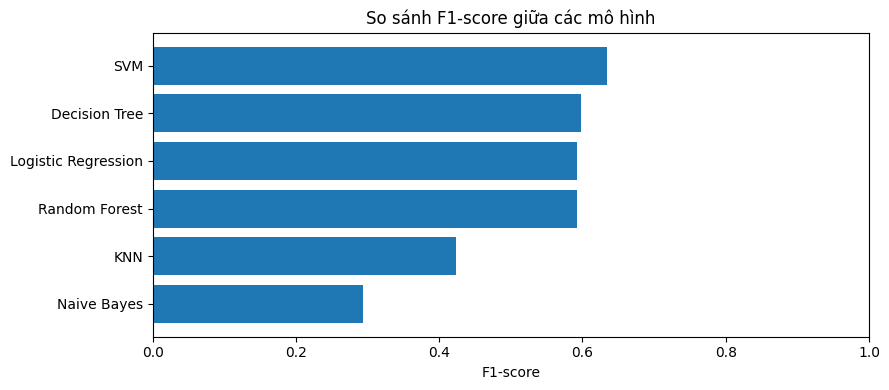

In [7]:
plt.figure(figsize=(9, 4))
plot_data = model_results.sort_values('f1')
plt.barh(plot_data['mo_hinh'], plot_data['f1'])
plt.title('So sánh F1-score giữa các mô hình')
plt.xlabel('F1-score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


Kết luận câu 3:

- Nếu ưu tiên `F1-score`, mô hình tốt nhất trong lần thử này là **SVM**, với F1 khoảng 0,634. SVM cân bằng khá tốt giữa `precision` và `recall`, tức vừa tìm được nhiều phiên có khả năng mua, vừa không dự đoán sai quá nhiều.
- Nếu ưu tiên `ROC-AUC` hoặc `accuracy`, **Random Forest** nổi bật hơn, với accuracy khoảng 0,897 và ROC-AUC khoảng 0,921. Tuy nhiên recall của Random Forest thấp hơn, nghĩa là bỏ sót nhiều phiên có mua hơn so với SVM hoặc Decision Tree.
- **Decision Tree** có recall cao, nhưng precision thấp hơn, nghĩa là bắt được nhiều người mua nhưng cũng dự đoán nhầm nhiều phiên không mua thành mua.

Với câu hỏi là dự đoán một phiên truy cập có đến được giao dịch thành công hay không, với dữ liệu bị lệch lặp, nên lựa chọn hợp lý nhất theo F1-score là **SVM**. Nếu mục tiêu kinh doanh là xếp hạng xác suất mua hàng cho marketing hoặc remarketing, có thể cân nhắc **Random Forest** vì ROC-AUC cao hơn.